## Stage 1: Boundary / Sandhi Window Detection

In [1]:
import pandas as pd
import numpy as np
import re

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
DATA_XLSX = "/kaggle/input/sandhi-data/sandhi_data.xlsx"
df = pd.read_excel(DATA_XLSX)

print("Shape:", df.shape)
df = df.rename(columns={
    df.columns[0]: "raw",
    df.columns[1]: "split"
})
print("Columns:", df.columns.tolist())
df.head(5)

Shape: (13930, 2)
Columns: ['raw', 'split']


,raw,split
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः
1,शब्द इव,शब्दः+इव
2,इत इतः,इतः+इतः
3,कुतो नु,कुतः+नु
4,खल्वेष समुत्थितो समुत्थितो ध्वनिः,खलु+एषः+समुत्थितः+समुत्थितः+ध्वनिः


In [3]:
def extract_word_pairs(raw, split):
    if not isinstance(raw, str) or not isinstance(split, str):
        return []

    raw = raw.strip()
    split = split.strip()

    if raw == "" or split == "":
        return []

    raw_words = raw.split()
    split_parts = split.split("+")

    pairs = []
    idx = 0

    for raw_word in raw_words:
        combined = ""
        while idx < len(split_parts):
            combined += split_parts[idx]
            idx += 1
            if len(combined.replace("्", "")) >= len(raw_word.replace("्", "")):
                pairs.append((raw_word, combined))
                break
            combined += "+"

    return pairs

samples = []
for _, row in df.iterrows():
    samples.extend(extract_word_pairs(row["raw"], row["split"]))

word_df = pd.DataFrame(samples, columns=["sandhied", "gold_split"])
word_df.head(10)

,sandhied,gold_split
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः
1,शब्द,शब्दः
2,इव,इव
3,इत,इतः
4,इतः,इतः
5,कुतो,कुतः
6,नु,नु
7,खल्वेष,खलु+एषः
8,समुत्थितो,समुत्थितः
9,समुत्थितो,समुत्थितः


In [4]:
def get_boundary_positions(split_word):
    parts = split_word.split("+")
    if len(parts) <= 1:
        return []
    return [len(parts[0])]


word_df["boundary_positions"] = word_df["gold_split"].apply(get_boundary_positions)
word_df.head()

,sandhied,gold_split,boundary_positions
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः,[6]
1,शब्द,शब्दः,[]
2,इव,इव,[]
3,इत,इतः,[]
4,इतः,इतः,[]


In [5]:
def boundary_vector(word, positions):
    vec = [0] * len(word)
    for p in positions:
        if p < len(word):
            vec[p] = 1
    return vec


word_df["boundary_vector"] = word_df.apply(
    lambda r: boundary_vector(r["sandhied"], r["boundary_positions"]),
    axis=1
)

In [6]:
PAD = "<PAD>"

chars = set()
for w in word_df["sandhied"]:
    chars.update(w)

char2idx = {PAD: 0}
for ch in sorted(chars):
    char2idx[ch] = len(char2idx)

idx2char = {v: k for k, v in char2idx.items()}
VOCAB_SIZE = len(char2idx)

print("Vocab size:", VOCAB_SIZE)

Vocab size: 81


In [7]:
MAX_LEN = word_df["sandhied"].apply(len).max()

def encode(word):
    return [char2idx[c] for c in word]

def pad(seq):
    return seq + [0] * (MAX_LEN - len(seq))


word_df["input_ids"] = word_df["sandhied"].apply(lambda x: pad(encode(x)))
word_df["labels"] = word_df["boundary_vector"].apply(lambda x: pad(x))

In [8]:
class SandhiBoundaryDataset(Dataset):
    def __init__(self, df):
        self.X = df["input_ids"].tolist()
        self.y = df["labels"].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float)
        )

In [9]:
train_df, val_df = train_test_split(word_df, test_size=0.1, random_state=42)

train_loader = DataLoader(SandhiBoundaryDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(SandhiBoundaryDataset(val_df), batch_size=32)

In [10]:
class BoundaryBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out).squeeze(-1)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BoundaryBiLSTM(VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

100%|██████████| 551/551 [00:03<00:00, 162.06it/s]


Epoch 1: Loss = 0.0283


100%|██████████| 551/551 [00:02<00:00, 204.73it/s]


Epoch 2: Loss = 0.0078


100%|██████████| 551/551 [00:02<00:00, 205.52it/s]


...

Epoch 8: Loss = 0.0028


100%|██████████| 551/551 [00:02<00:00, 203.49it/s]


Epoch 9: Loss = 0.0025


100%|██████████| 551/551 [00:02<00:00, 203.55it/s]

Epoch 10: Loss = 0.0022


In [12]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        preds = (torch.sigmoid(model(x)) > 0.5)
        correct += (preds == y.bool()).sum().item()
        total += y.numel()

print("Boundary accuracy:", correct / total)

Boundary accuracy: 0.9987666628981366


In [13]:
def predict_boundary(word):
    model.eval()

    # encode + pad
    encoded = [char2idx[c] for c in word]
    encoded = encoded + [0] * (MAX_LEN - len(encoded))
    x = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    # pick max probability position
    boundary = int(probs.argmax())
    return boundary, probs

In [14]:
samples = word_df.sample(5)

for _, row in samples.iterrows():
    word = row["sandhied"]
    gold = row["boundary_positions"]

    pred_boundary, probs = predict_boundary(word)

    print("Word :", word)
    print("Gold :", gold)
    print("Pred :", pred_boundary)
    print("-" * 40)

Word : तथाप्यहं
Gold : [5]
Pred : 5
----------------------------------------
Word : निकुम्भश्च
Gold : [8]
Pred : 8
----------------------------------------
Word : विनैवेति
Gold : [4]
Pred : 4
----------------------------------------
Word : लवणाल्लुक्
Gold : [6]
Pred : 6
----------------------------------------
Word : स्थितधीर्मुनिरुच्यते
Gold : [8]
Pred : 8
----------------------------------------


In [15]:
model_stage1 = model
char2idx_stage1 = char2idx
idx2char_stage1 = idx2char
MAX_LEN_STAGE1 = MAX_LEN

## def cer(pred, gold):
    import editdistance
    denom = max(len(gold), len(pred), 1)
    return editdistance.eval(pred, gold) / denom
Stage 2: Restoration (Seq2Seq)

In [37]:
PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"
WINDOW_SIZE = 25
SEP = "|"

def make_window(word, boundary):
    boundary = int(boundary)
    left = word[max(0, boundary - WINDOW_SIZE):boundary]
    right = word[boundary:boundary + WINDOW_SIZE]
    return left + SEP + right

In [38]:
stage2_df = word_df.copy()

stage2_df["boundary"] = stage2_df["boundary_positions"].apply(
    lambda x: int(x[0]) if isinstance(x, list) and len(x) > 0 else None
)

stage2_df = stage2_df.dropna(subset=["boundary"])

stage2_df["input"] = stage2_df.apply(
    lambda r: make_window(r["sandhied"], r["boundary"]),
    axis=1
)

stage2_df["target"] = stage2_df["gold_split"].apply(
    lambda x: SOS + x + EOS
)

In [39]:
chars = set()

for t in stage2_df["input"]:
    chars.update(t)
for t in stage2_df["target"]:
    chars.update(t)

chars.update([PAD, SOS, EOS])

char2idx_stage2 = {PAD: 0}
for ch in sorted(chars):
    char2idx_stage2[ch] = len(char2idx_stage2)

idx2char_stage2 = {v: k for k, v in char2idx_stage2.items()}
VOCAB_SIZE = len(char2idx_stage2)


In [40]:
MAX_IN_LEN = stage2_df["input"].apply(len).max()
MAX_OUT_LEN = stage2_df["target"].apply(len).max()

def encode_s2(text):
    return [char2idx_stage2[c] for c in text]

def pad_s2(seq, max_len):
    return seq + [0] * (max_len - len(seq))


stage2_df["enc_in"] = stage2_df["input"].apply(
    lambda x: pad_s2(encode_s2(x), MAX_IN_LEN)
)
stage2_df["dec_out"] = stage2_df["target"].apply(
    lambda x: pad_s2(encode_s2(x), MAX_OUT_LEN)
)

In [41]:
class SandhiRestoreDataset(Dataset):
    def __init__(self, df):
        self.X = df["enc_in"].tolist()
        self.y = df["dec_out"].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long)
        )

train_df, val_df = train_test_split(stage2_df, test_size=0.1, random_state=42)

train_loader = DataLoader(
    SandhiRestoreDataset(train_df),
    batch_size=32,
    shuffle=True
)

In [42]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb=64, hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(
            emb, hid, batch_first=True, bidirectional=True
        )

    def forward(self, x):
        x = self.emb(x)
        outputs, (h, c) = self.lstm(x)
    
        h = h.view(2, -1, h.size(2)).sum(dim=0).unsqueeze(0)
        c = c.view(2, -1, c.size(2)).sum(dim=0).unsqueeze(0)
    
        return outputs, (h, c)

In [43]:
class AttnDecoder(nn.Module):
    def __init__(self, vocab, emb=64, hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb + 2*hid, hid, batch_first=True)
        self.attn = nn.Linear(hid + 2*hid, 1)
        self.fc = nn.Linear(hid, vocab)

    def forward(self, enc_out, prev_char, hidden):
        h, c = hidden
    
        emb = self.emb(prev_char)
        query = h[-1].unsqueeze(1).repeat(1, enc_out.size(1), 1)
        attn_scores = self.attn(torch.cat([query, enc_out], dim=-1))
        attn_weights = torch.softmax(attn_scores, dim=1)
    
        context = (attn_weights * enc_out).sum(dim=1).unsqueeze(1)
    
        lstm_input = torch.cat([emb, context], dim=-1)
        out, (h, c) = self.lstm(lstm_input, (h, c))
    
        logits = self.fc(out.squeeze(1))
        return logits, (h, c)

In [44]:
class SandhiRestorer(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        self.encoder = Encoder(vocab)
        self.decoder = AttnDecoder(vocab)

    def forward(self, src, tgt):
        enc_out = self.encoder(src)
        hidden = (
            torch.zeros(1, src.size(0), 128, device=src.device),
            torch.zeros(1, src.size(0), 128, device=src.device),
        )

        loss_logits = []
        cur = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt.size(1)):
            logits, hidden = self.decoder(enc_out, cur, hidden)
            loss_logits.append(logits)
            cur = tgt[:, t].unsqueeze(1)

        return torch.stack(loss_logits, dim=1)

In [46]:
model_stage2 = SandhiRestorer(VOCAB_SIZE).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model_stage2.parameters(), lr=1e-3)
stage2_losses = []

EPOCHS = 20
for epoch in range(EPOCHS):
    model_stage2.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        enc_out, (h, c) = model_stage2.encoder(x)

        cur = y[:, 0].unsqueeze(1)
        loss = 0
        steps = 0

        for t in range(1, y.size(1)):
            logits, (h, c) = model_stage2.decoder(enc_out, cur, (h, c))
            step_logits = logits.squeeze(1)
            target = y[:, t]

            mask = target != 0
            if mask.any():
                loss += criterion(step_logits[mask], target[mask])
                steps += 1

            cur = target.unsqueeze(1)

        loss = loss / max(steps, 1)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    stage2_losses.append(avg_loss)

    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f}")

Epoch 1: Loss 1.7964
Epoch 2: Loss 1.2758
Epoch 3: Loss 1.0941
Epoch 4: Loss 0.9483
Epoch 5: Loss 0.8491
Epoch 6: Loss 0.7439
Epoch 7: Loss 0.6575
Epoch 8: Loss 0.6028
Epoch 9: Loss 0.5508
Epoch 10: Loss 0.4933
Epoch 11: Loss 0.4447
Epoch 12: Loss 0.4242
Epoch 13: Loss 0.3929
Epoch 14: Loss 0.3605
Epoch 15: Loss 0.3324
Epoch 16: Loss 0.3065
Epoch 17: Loss 0.2915
Epoch 18: Loss 0.2762
Epoch 19: Loss 0.2563
Epoch 20: Loss 0.2517


In [47]:
def restore_stage2(word, boundary, max_len=40):
    model_stage2.eval()

    window = make_window(word, boundary)
    src = torch.tensor(
        [pad_s2(encode_s2(window), MAX_IN_LEN)],
        device=device
    )

    enc_out, (h, c) = model_stage2.encoder(src)
    hidden = (h, c)

    cur = torch.tensor([[char2idx_stage2[SOS]]], device=device)
    result = []

    for _ in range(max_len):
        logits, hidden = model_stage2.decoder(enc_out, cur, hidden)
        next_id = logits.argmax(-1).item()
        ch = idx2char_stage2[next_id]

        if ch == EOS:
            break

        result.append(ch)
        cur = torch.tensor([[next_id]], device=device)

    return "".join(result)


In [63]:
def predict_boundary_stage1(word):
    model_stage1.eval()

    encoded = [char2idx_stage1[c] for c in word]
    encoded += [0] * (MAX_LEN_STAGE1 - len(encoded))

    x = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model_stage1(x)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    boundary = int(probs.argmax())
    return boundary, probs

In [49]:
def sandhi_split_end_to_end(word):
    boundary = predict_boundary_stage1(word)
    split = restore_stage2(word, boundary)
    return split, boundary

In [65]:
def boundary_accuracy(df):
    correct = 0
    total = 0

    for _, row in df.iterrows():
        if not row["boundary_positions"]:
            continue

        word = row["sandhied"]
        gold = row["boundary_positions"][0]
        pred,_ = predict_boundary_stage1(word)

        if pred == gold:
            correct += 1
        total += 1

    return correct / total if total > 0 else 0.0

b_acc = boundary_accuracy(word_df)
print(f"Stage-1 Boundary Accuracy: {b_acc:.4f}")

Stage-1 Boundary Accuracy: 0.9340


In [61]:
def cer(pred, gold):
    import editdistance
    denom = max(len(gold), len(pred), 1)
    return editdistance.eval(pred, gold) / denom

def average_cer(df, max_samples=300, seed=42):
    import editdistance

    df_eval = df.sample(
        n=min(max_samples, len(df)),
        random_state=seed
    )

    scores = []

    for _, row in df_eval.iterrows():
        word = row["sandhied"]
        gold = row["gold_split"]
        pred, _ = sandhi_split_end_to_end(word)

        score = cer(pred, gold)
        scores.append(score)

    return sum(scores) / len(scores), scores
    
avg_cer, cer_scores = average_cer(word_df, max_samples=300)
print(avg_cer)
print(min(cer_scores), max(cer_scores))

0.8211062378167642
0.5 1.0


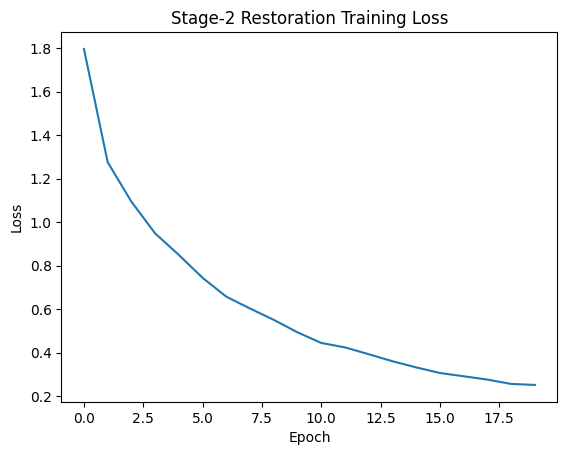

In [56]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(stage2_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage-2 Restoration Training Loss")
plt.show()


In [73]:
def collect_probs_and_labels(df):
    y_true = []
    y_scores = []

    for _, row in df.iterrows():
        if not row["boundary_positions"]:
            continue

        word = row["sandhied"]
        gold = row["boundary_positions"][0]

        _, probs = predict_boundary_stage1(word)

        for i in range(len(word)):
            y_true.append(1 if i == gold else 0)
            y_scores.append(probs[i])

    return y_true, y_scores


y_true, y_scores = collect_probs_and_labels(word_df)


In [74]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.linspace(0.1, 0.9, 9)
f1_scores = []

for t in thresholds:
    y_pred = [1 if s >= t else 0 for s in y_scores]

    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    f1_scores.append(f1)


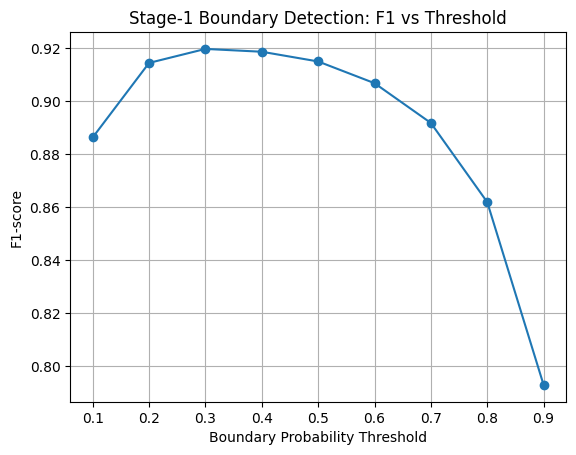

In [75]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f1_scores, marker="o")
plt.xlabel("Boundary Probability Threshold")
plt.ylabel("F1-score")
plt.title("Stage-1 Boundary Detection: F1 vs Threshold")
plt.grid(True)
plt.show()


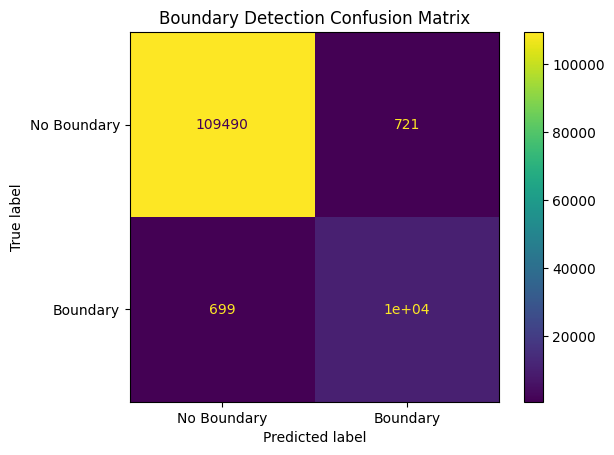

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Boundary", "Boundary"]
)

disp.plot()
plt.title("Boundary Detection Confusion Matrix")
plt.show()


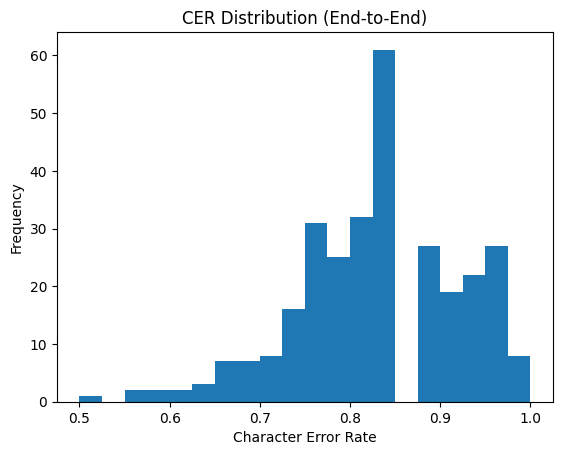

In [67]:
plt.figure()
plt.hist(cer_scores, bins=20)
plt.xlabel("Character Error Rate")
plt.ylabel("Frequency")
plt.title("CER Distribution (End-to-End)")
plt.show()


In [68]:
torch.save({
    "model_state": model_stage1.state_dict(),
    "char2idx": char2idx_stage1,
    "MAX_LEN": MAX_LEN_STAGE1
}, "stage1_boundary.pt")

torch.save({
    "model_state": model_stage2.state_dict(),
    "char2idx": char2idx_stage2,
    "idx2char": idx2char_stage2,
    "MAX_IN_LEN": MAX_IN_LEN,
    "SOS": SOS,
    "EOS": EOS,
    "PAD": PAD
}, "stage2_restoration.pt")